In [1]:
snnapdatapath = "/media/udickman/uri-external-drive/SNNAP_data/fig5"
excelpath = "../Excel_files"
figpath = "../figs"
fig_prefix = "Dickman_etal_Results"
excelfile = "fig5-fig9.xlsx"

# Run this cell, then comment out the lines below and restart the kernel.
# import os
# !yes | neuronpyxl -f gen_mods --file {os.path.join(excelpath,excelfile)}

In [2]:
import sys
import os
sys.path.append("../")
from neuron import h
import scienceplots
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from neuronpyxl import network
plt.style.use(["no-latex", "notebook"])

In [13]:
def remove_axes(ax,remove_x=True,remove_y=False):
    # For aesthetics
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if remove_x:
        ax.spines['bottom'].set_visible(False)
        ax.set_xticks([])
    if remove_y:
        ax.spines['left'].set_visible(False)
        ax.set_yticks([])
        
def plot_vertical_scalebar(ax,scalebar_length=10,bar_width=0.25,offset=0,yoffset=10):
    from matplotlib.patches import Rectangle
    # Get axis limits
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Coordinates for bottom-right corner
    x_start = xlim[1] - offset - bar_width
    y_start = ylim[0] + offset + yoffset

    scalebar = Rectangle((x_start, y_start), width=bar_width, height=scalebar_length,
                        color='black', linewidth=0, zorder=10)

    ax.add_patch(scalebar)

    # Optional: Add text label
    ax.text(x_start-0.001, y_start + scalebar_length / 2, f'{scalebar_length} mV',
            va='center', ha='right', color='black', fontsize=14)

In [14]:
nb = network.NetworkBuilder(params_file=os.path.join(excelpath, excelfile), sim_name="excitability",
                            noise=None,dt=-1,integrator=2,atol=1e-5,eq_time=1000,simdur=9000,seed=False)
nb.run()
tvec = np.arange(0,9000,step=0.05)
data = pd.DataFrame(nb.get_interpolated_cell_data("B4",tvec))

Added Cell(gid=3, name=B4) to the network.
Loading simulation parameters...
Running simulation...


In [15]:
snnapdata = pd.read_csv(os.path.join(snnapdatapath,"excitability.smu.out"), sep="\t").dropna(axis=1).dropna(axis=0)
snnapdata.columns = ["t", "V", "I_leak", "I_na", "I_k", "I_kcas", "cai", "I_app"]
snnapdata = snnapdata[snnapdata["t"]>=10]
snnapdata["t"] -= 10

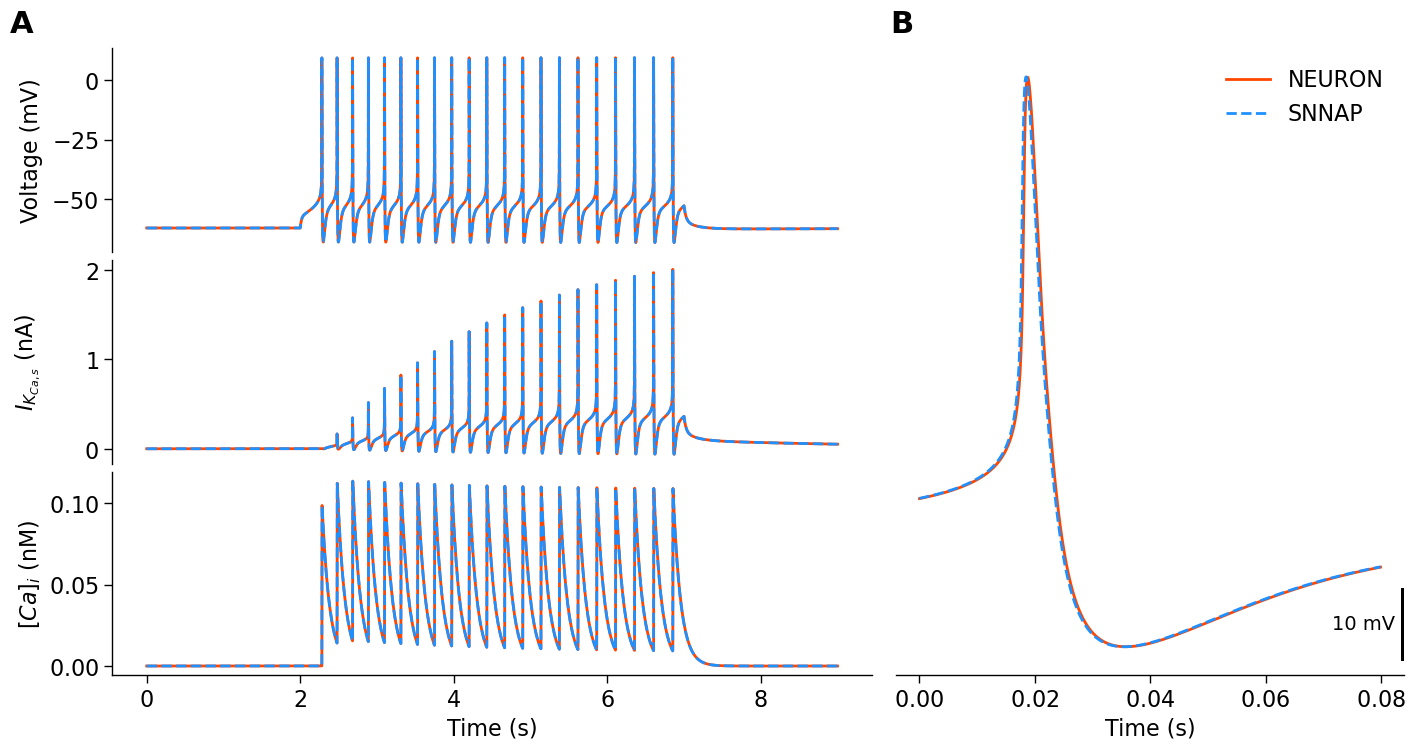

In [18]:
t = data["t"] / 1000
tsnnap = np.array(snnapdata["t"])
fig = plt.figure(figsize=(14,7),constrained_layout=True)
sfigs = fig.subfigures(1,2, width_ratios=(2,1.2))
ax1 = sfigs[0].subplots(3,1)
ax2 = sfigs[1].subplots(1,1)

snnapcolor = "dodgerblue"
nrncolor = "orangered"

ax1[0].plot(t,data["V"],color=nrncolor)
ax1[0].plot(tsnnap,snnapdata["V"],color=snnapcolor,linestyle="dashed")
ax1[0].set_ylabel("Voltage (mV)")
remove_axes(ax1[0])
ax1[1].plot(t,data["I_kcas"],color=nrncolor)
ax1[1].plot(tsnnap,snnapdata["I_kcas"],color=snnapcolor,linestyle="dashed")
ax1[1].set_ylabel(r"$I_{K_{Ca,s}}$ (nA)")
remove_axes(ax1[1])
ax1[2].plot(t,data["cai"]*1e6,color=nrncolor)
ax1[2].plot(tsnnap,snnapdata["cai"],color=snnapcolor,linestyle="dashed")
ax1[2].set_ylabel(r"$[Ca]_i$ (nM)")
ax1[2].set_xlabel("Time (s)")
remove_axes(ax1[2],remove_x=False,remove_y=False)

start = 97600
end = 99200
ax2.plot(t[start:end]-t[start],data["V"][start:end],label="NEURON",color=nrncolor)
ax2.plot(tsnnap[start:end]-tsnnap[start],snnapdata["V"][start:end],label="SNNAP",color=snnapcolor,linestyle="dashed")
remove_axes(ax2,remove_x=False,remove_y=True)
ax2.legend(frameon=False)
ax2.set_xlabel("Time (s)")
plot_vertical_scalebar(ax2,bar_width=0.0005,offset=0,yoffset=2)

sfig_labels = ['A', 'B']

for subfig, label in zip(sfigs, sfig_labels):
    # Add label to the upper left of each subfigure
    subfig.suptitle(label, x=0.0, y=1.05, ha='left', va='top', fontsize=22, fontweight='bold')
    
sfigs[0].align_ylabels()

fig.savefig(os.path.join(figpath,f"{fig_prefix}_regulation.jpg"),bbox_inches="tight",dpi=300)